In [2]:
import cv2
import numpy as np
from colorcet import rainbow
from numba import jit, int64, float64
try:
    from numba.experimental import jitclass
except ModuleNotFoundError:
    from numba import jitclass

import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [7]:
a = [351283.854899,
351283.8743859,
351283.8960119,
351283.9074109,
351283.9274779,
351283.9484605,
351283.9673788,
351283.986926,
351284.1430983,
351284.1676654]
np.mean(np.diff(a))

0.0347518222212481

In [134]:
rows, cols = 100, 80
gradient = np.linspace(0, 20, cols)
array = np.tile(gradient, (rows, 1))

In [141]:
array.max()

20.0

(30, 20)

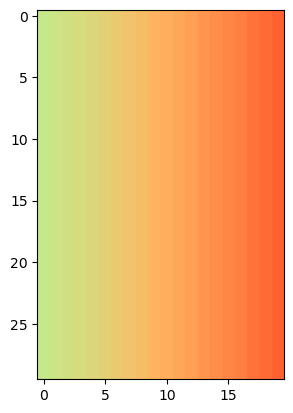

In [177]:
wnd_pos = [20, 50]
wnd_dim = [30, 20]
im = array[
                    wnd_pos[0]: wnd_pos[0] + wnd_dim[0],
                    wnd_pos[1]: wnd_pos[1] + wnd_dim[1],
                    ]
plt.imshow(im, cmap = 'rainbow', vmin = 0, vmax = 20)
im.shape

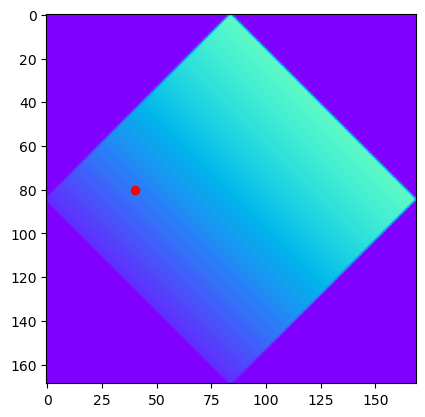

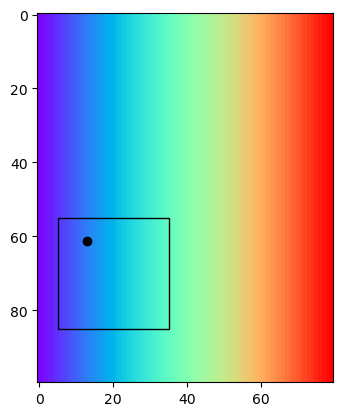

In [180]:
theta = np.pi/4
im_og = array
border_margin = 5
wnd_pos = [60 - border_margin, 10 - border_margin]
wnd_dim = [20 + 2*border_margin, 20 + 2* border_margin]
im = im_og[
                    wnd_pos[0]: wnd_pos[0] + wnd_dim[0],
                    wnd_pos[1]: wnd_pos[1] + wnd_dim[1],
                    ].copy()

# Upsampling factor
scale = 4.0
im_up = cv2.resize(im, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

(h, w) = im_up.shape[:2]
cos, sin = abs(np.cos(theta)), abs(np.sin(theta))
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)

center = (w / 2, h / 2)  # rotate from the center of the upsampled image
M = cv2.getRotationMatrix2D(center, np.rad2deg(theta), 1.0)  # 1.0 = no scaling
M[0,2] += (new_w - w) / 2
M[1,2] += (new_h - h) / 2
M_inv = cv2.invertAffineTransform(M)

# Warp the upsampled image
rotated_im = cv2.warpAffine(im_up, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderValue=0)

# dot coordinates — upscale too
dot_up = (40, 80)  # scale the dot to match the upsampled image

# Show rotated image with dot
plt.imshow(rotated_im, cmap='rainbow', vmin = 0, vmax = 20)
plt.scatter(dot_up[0], dot_up[1], color='red')

# Reverse the transformation
dot_after = np.array([dot_up[0], dot_up[1], 1.0])
dotx_after, doty_after = (M_inv @ dot_after)[:2]

# Rescale back to original resolution
dotx_final = wnd_pos[1] + dotx_after / scale
doty_final = wnd_pos[0] + doty_after/ scale

# Plot on original image
fig, ax = plt.subplots()
ax.imshow(im_og, cmap='rainbow',  vmin = 0, vmax = 20)
polygon = patches.Polygon([
                            [wnd_pos[1], wnd_pos[0]], 
                            [wnd_pos[1] + wnd_dim[1], wnd_pos[0]],
                            [wnd_pos[1] + wnd_dim[1],wnd_pos[0] + wnd_dim[0]],
                            [wnd_pos[1], wnd_pos[0] + wnd_dim[0]],
                            
                           ],edgecolor = 'black', facecolor = None, fill = False)
ax.add_patch(polygon)
ax.scatter(dotx_final, doty_final, color='black')
plt.show()

In [160]:
rotated_im = cv2.warpAffine(im, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderValue=0)

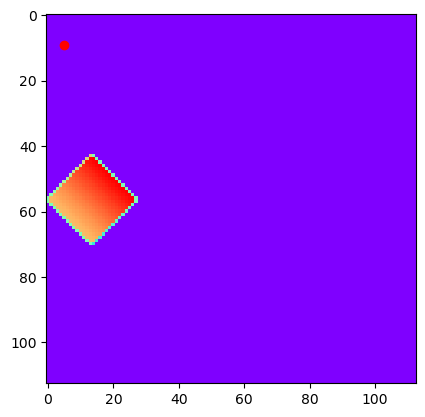

In [147]:
dot = (5, 9)
fig = plt.imshow(rotated_im, cmap = 'rainbow')

plt.scatter(dot[0], dot[1], color = 'red')

In [108]:
dot_after = np.array([dot[0], dot[1], 1.0])
dotx_after, doty_after = (M_inv @ dot_after)[:2]

In [109]:
(M_inv @ dot_after)[:2]

array([1.17157288, 6.41421356])

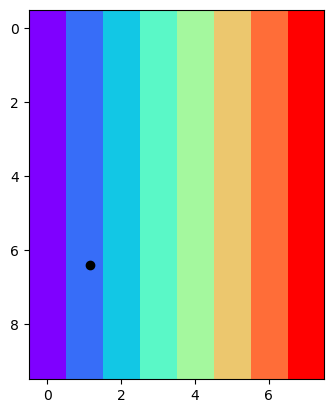

In [110]:
plt.imshow(im, cmap = 'rainbow')
plt.scatter(dotx_after, doty_after, color = 'black')

In [118]:
a = [((12, 13),)]
a[0][0][::-1]

(13, 12)